# Notebook 01: Explore Labeled Data

## Learning Goals
- Understand what labeled data looks like for LLM-as-Judge evaluation
- Learn what makes a good ground truth label
- Explore the structure of the dataset
- Identify patterns, edge cases, and potential challenges

## What is Labeled Data?
**Labeled data** is data that has been manually reviewed and tagged with the "correct answer" (ground truth). In our case:
- **Query**: What the user asked for (e.g., "vegan pasta recipe")
- **Response**: What the Recipe Bot provided
- **Label**: Whether the response correctly adheres to dietary restrictions (PASS or FAIL)
- **Reasoning**: Why it passed or failed

This labeled data serves as our **ground truth** - the source of truth we'll use to train and evaluate our LLM judge.

## Step 1: Import Libraries

We'll use:
- **pandas**: For loading and analyzing tabular data (CSV files)
- **json**: For working with JSON data if needed
- **matplotlib/seaborn**: For creating visualizations

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options so we can see full text in pandas output
pd.set_option('display.max_colwidth', None)  # Show full text in columns
pd.set_option('display.max_rows', 100)       # Show up to 100 rows

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Load the Labeled Data

The labeled data is stored in `data/labeled_traces.csv`. Let's load it and see what it looks like.

In [2]:
# Load the labeled traces
# The '..' means "go up one directory level" from notebooks/ to my_work/, then up again to hw3/
labeled_data = pd.read_csv('../../data/labeled_traces.csv')

print(f"Loaded {len(labeled_data)} labeled traces")
print(f"\nDataset shape: {labeled_data.shape[0]} rows, {labeled_data.shape[1]} columns")

Loaded 101 labeled traces

Dataset shape: 101 rows, 11 columns


## Step 3: Examine the Structure

Let's see what columns we have and what data types they contain.

In [3]:
# Display column names and data types
print("Column Information:")
print(labeled_data.info())

print("\n" + "="*50 + "\n")
print("Column Names:")
for i, col in enumerate(labeled_data.columns, 1):
    print(f"{i}. {col}")

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   query                101 non-null    object 
 1   dietary_restriction  101 non-null    object 
 2   response             101 non-null    object 
 3   success              101 non-null    bool   
 4   error                0 non-null      float64
 5   trace_id             101 non-null    object 
 6   query_id             101 non-null    int64  
 7   label                101 non-null    object 
 8   reasoning            101 non-null    object 
 9   confidence           101 non-null    object 
 10  labeled              101 non-null    bool   
dtypes: bool(2), float64(1), int64(1), object(7)
memory usage: 7.4+ KB
None


Column Names:
1. query
2. dietary_restriction
3. response
4. success
5. error
6. trace_id
7. query_id
8. label
9. reasoning
10. confidence
11. labe

## Step 4: Look at Sample Examples

Let's examine a few examples to understand what the data looks like.

### 🤔 Reflection Questions:
As you read through these examples, think about:
1. Do the labels (PASS/FAIL) make sense to you?
2. Is the reasoning clear and convincing?
3. Are there any ambiguous cases?

In [4]:
# Display the first 3 examples
print("First 3 examples in the dataset:\n")
labeled_data.head(3)

First 3 examples in the dataset:



,query,dietary_restriction,response,success,error,trace_id,query_id,label,reasoning,confidence,labeled
0,Gluten-light recipe - I'm not celiac just sensitive,gluten-free,"Absolutely! Here's a delicious and easy Gluten-Light **Lemon Herb Quinoa Salad** perfect for two people.\n\n### Ingredients:\n- 1 cup quinoa\n- 2 cups water\n- 1 medium cucumber, diced\n- 1/4 cup fresh parsley, chopped\n- 1/4 cup fresh mint, chopped\n- 1 lemon (for juice and zest)\n- 2 tablespoons olive oil\n- Salt and pepper to taste\n- Optional: 1/4 cup crumbled feta cheese or chopped cherry tomatoes\n\n### Instructions:\n\n1. **Rinse the Quinoa:** Place the quinoa in a fine mesh strainer and rinse thoroughly under cold water to remove any bitterness.\n\n2. **Cook the Quinoa:** In a medium pot, combine the rinsed quinoa and water. Bring it to a boil over medium-high heat. Once boiling, reduce the heat to low, cover with a lid, and simmer for 15 minutes, or until the water is absorbed and the quinoa is fluffy.\n\n3. **Let it Cool:** Remove the pot from heat. Fluff the quinoa with a fork. Let it cool to room temperature; you can spread it out on a baking sheet to speed this up.\n\n4. **Prepare the Dressing:** While the quinoa cools, in a small bowl, squeeze the juice of one lemon, add the lemon zest, olive oil, salt, and pepper. Whisk together until well combined.\n\n5. **Assemble the Salad:** In a large bowl, combine the cooled quinoa, diced cucumber, chopped herbs, and any optional ingredients like feta or cherry tomatoes.\n\n6. **Dress and Toss:** Pour the lemon dressing over the salad and gently toss to combine all flavors. Adjust salt and pepper to taste.\n\n7. **Serve:** Divide the salad onto two plates and enjoy immediately or refrigerate for 30 minutes to allow flavors to meld.\n\n**Serving Size:** 2 servings\n\nThis refreshing quinoa salad is light, nutritious, and naturally gluten-light. Perfect as a main or side dish!",True,NaN,48_3,48,FAIL,"The recipe is labeled as 'Gluten-Light' and not explicitly 'Gluten-Free'. Quinoa is naturally gluten-free, making it suitable for a gluten-free diet. However, the recipe includes an optional ingredient, feta cheese, which is gluten-free but could be a concern if cross-contaminated during processing. The recipe does not include any gluten-containing grains like wheat, barley, or rye. The preparation methods do not introduce gluten. However, since the query specifies a gluten-free dietary restriction, the use of 'gluten-light' terminology and optional ingredients that could potentially be cross-contaminated might not fully adhere to strict gluten-free standards. Therefore, while the recipe is likely safe for someone who is gluten-sensitive, it does not strictly adhere to a gluten-free diet due to the potential for cross-contamination and the 'gluten-light' designation.",MEDIUM,True
1,Nut-free lunch that's safe for my kid's school,nut-free,"Certainly! Here's a tasty, nut-free, school-safe lunch idea: **Chicken and Veggie Wraps**. This is a nutritious and portable option that kids love.\n\n### Ingredients (for 2 servings):\n- 2 large whole wheat tortillas\n- 1 cooked chicken breast, sliced\n- 1 small cucumber, thinly sliced\n- 1 small red bell pepper, thinly sliced\n- 1 carrot, grated\n- 2 tablespoons plain Greek yogurt\n- 1 teaspoon Dijon mustard (optional)\n- Salt and pepper to taste\n- Lettuce leaves (romaine or iceberg)\n\n### Instructions:\n\n1. **Prepare the Spread:**\n - In a small bowl, mix the plain Greek yogurt with the Dijon mustard (if using). Add a pinch of salt and pepper, and stir to combine. This will add flavor and moisture to the wraps.\n\n2. **Warm the Tortillas:**\n - Lightly warm the tortillas in a dry skillet over medium heat for about 10 seconds on each side, or microwave them for 10 seconds. Warming makes them more pliable and easier to roll.\n\n3. **Assemble the Wraps:**\n - Lay each tortilla flat on a clean plate.\n - Spread half of the yogurt mixture evenly over the center of each tortilla

### Let's look at a PASS example in detail

In [5]:
# Find a PASS example
pass_examples = labeled_data[labeled_data['label'] == 'PASS']

if len(pass_examples) > 0:
    example = pass_examples.iloc[0]
    
    print("=" * 80)
    print("EXAMPLE: PASS")
    print("=" * 80)
    print(f"\n📝 QUERY: {example['query']}")
    print(f"\n🥗 DIETARY RESTRICTION: {example['dietary_restriction']}")
    print(f"\n🤖 BOT RESPONSE:\n{example['response'][:500]}...")  # Show first 500 chars
    print(f"\n✅ LABEL: {example['label']}")
    print(f"\n💭 REASONING: {example['reasoning']}")
    print(f"\n📊 CONFIDENCE: {example.get('confidence', 'N/A')}")
else:
    print("No PASS examples found")

EXAMPLE: PASS

📝 QUERY: Nut-free lunch that's safe for my kid's school

🥗 DIETARY RESTRICTION: nut-free

🤖 BOT RESPONSE:
Certainly! Here's a tasty, nut-free, school-safe lunch idea: **Chicken and Veggie Wraps**. This is a nutritious and portable option that kids love.

### Ingredients (for 2 servings):
- 2 large whole wheat tortillas
- 1 cooked chicken breast, sliced
- 1 small cucumber, thinly sliced
- 1 small red bell pepper, thinly sliced
- 1 carrot, grated
- 2 tablespoons plain Greek yogurt
- 1 teaspoon Dijon mustard (optional)
- Salt and pepper to taste
- Lettuce leaves (romaine or iceberg)

### Instructions:
...

✅ LABEL: PASS

💭 REASONING: The recipe for Chicken and Veggie Wraps adheres to the nut-free dietary restriction. None of the ingredients listed, such as whole wheat tortillas, chicken breast, cucumber, red bell pepper, carrot, Greek yogurt, Dijon mustard, salt, pepper, and lettuce, contain tree nuts or peanuts. The preparation method does not introduce any risk of cross-c

### Let's look at a FAIL example in detail

In [6]:
# Find a FAIL example
fail_examples = labeled_data[labeled_data['label'] == 'FAIL']

if len(fail_examples) > 0:
    example = fail_examples.iloc[0]
    
    print("=" * 80)
    print("EXAMPLE: FAIL")
    print("=" * 80)
    print(f"\n📝 QUERY: {example['query']}")
    print(f"\n🥗 DIETARY RESTRICTION: {example['dietary_restriction']}")
    print(f"\n🤖 BOT RESPONSE:\n{example['response'][:500]}...")  # Show first 500 chars
    print(f"\n❌ LABEL: {example['label']}")
    print(f"\n💭 REASONING: {example['reasoning']}")
    print(f"\n📊 CONFIDENCE: {example.get('confidence', 'N/A')}")
else:
    print("No FAIL examples found")

EXAMPLE: FAIL

📝 QUERY: Gluten-light recipe - I'm not celiac just sensitive

🥗 DIETARY RESTRICTION: gluten-free

🤖 BOT RESPONSE:
Absolutely! Here's a delicious and easy Gluten-Light **Lemon Herb Quinoa Salad** perfect for two people.

### Ingredients:
- 1 cup quinoa
- 2 cups water
- 1 medium cucumber, diced
- 1/4 cup fresh parsley, chopped
- 1/4 cup fresh mint, chopped
- 1 lemon (for juice and zest)
- 2 tablespoons olive oil
- Salt and pepper to taste
- Optional: 1/4 cup crumbled feta cheese or chopped cherry tomatoes

### Instructions:

1. **Rinse the Quinoa:** Place the quinoa in a fine mesh strainer and rinse thoroughl...

❌ LABEL: FAIL

💭 REASONING: The recipe is labeled as 'Gluten-Light' and not explicitly 'Gluten-Free'. Quinoa is naturally gluten-free, making it suitable for a gluten-free diet. However, the recipe includes an optional ingredient, feta cheese, which is gluten-free but could be a concern if cross-contaminated during processing. The recipe does not include any glute

## Step 5: Understand the Distribution

Let's analyze how the data is distributed across different categories.

### What is data distribution?
**Data distribution** tells us how our examples are spread across different categories. For example:
- How many PASS vs FAIL examples do we have?
- Which dietary restrictions appear most frequently?
- Are some restrictions harder to meet than others?

Label Distribution:
label
PASS    75
FAIL    26
Name: count, dtype: int64

Percentage:
label
PASS    74.257426
FAIL    25.742574
Name: proportion, dtype: float64


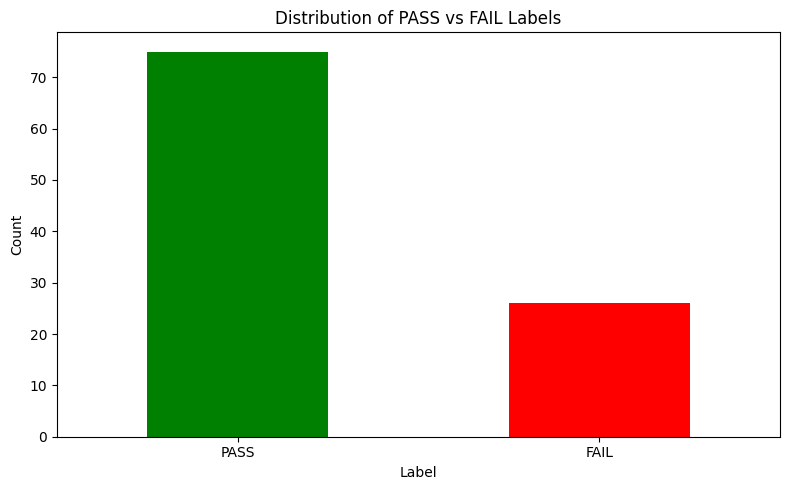

In [7]:
# Count PASS vs FAIL
label_counts = labeled_data['label'].value_counts()
print("Label Distribution:")
print(label_counts)
print(f"\nPercentage:")
print(labeled_data['label'].value_counts(normalize=True) * 100)

# Visualize
plt.figure(figsize=(8, 5))
label_counts.plot(kind='bar', color=['green', 'red'])
plt.title('Distribution of PASS vs FAIL Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Distribution by Dietary Restriction:
dietary_restriction
vegetarian           18
vegan                11
low-carb             11
gluten-free          10
paleo                10
keto                  7
pescatarian           6
diabetic-friendly     6
dairy-free            4
raw vegan             4
sugar-free            4
halal                 3
nut-free              2
kosher                2
whole30               2
low-sodium            1
Name: count, dtype: int64


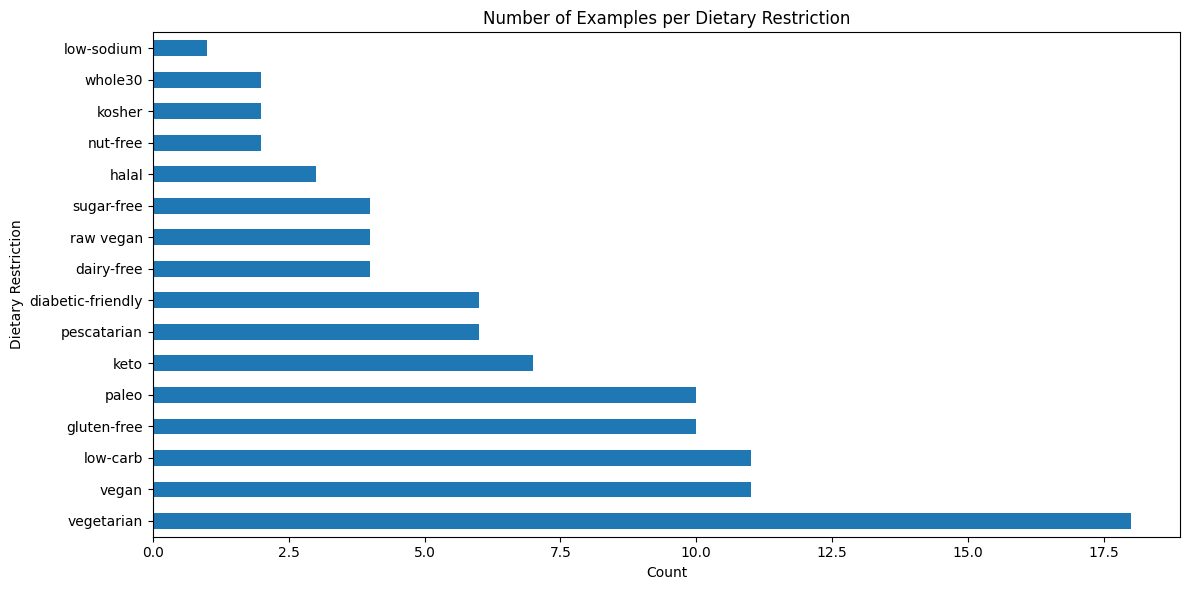

In [8]:
# Count by dietary restriction
restriction_counts = labeled_data['dietary_restriction'].value_counts()
print("Distribution by Dietary Restriction:")
print(restriction_counts)

# Visualize
plt.figure(figsize=(12, 6))
restriction_counts.plot(kind='barh')
plt.title('Number of Examples per Dietary Restriction')
plt.xlabel('Count')
plt.ylabel('Dietary Restriction')
plt.tight_layout()
plt.show()

## Step 6: Cross-Tabulation Analysis

Let's see how PASS/FAIL rates differ across dietary restrictions.

### What is a cross-tabulation?
A **cross-tabulation** (or crosstab) shows the relationship between two categorical variables. Here, we'll see:
- Which dietary restrictions have more PASS examples?
- Which ones have more FAIL examples?
- This helps us understand which restrictions the bot handles well vs poorly.

In [9]:
# Create cross-tabulation
crosstab = pd.crosstab(labeled_data['dietary_restriction'], 
                       labeled_data['label'], 
                       margins=True)
print("Cross-tabulation: Dietary Restriction vs Label")
print(crosstab)

Cross-tabulation: Dietary Restriction vs Label
label                FAIL  PASS  All
dietary_restriction                 
dairy-free              1     3    4
diabetic-friendly       0     6    6
gluten-free             7     3   10
halal                   0     3    3
keto                    0     7    7
kosher                  0     2    2
low-carb                4     7   11
low-sodium              0     1    1
nut-free                0     2    2
paleo                   5     5   10
pescatarian             0     6    6
raw vegan               1     3    4
sugar-free              2     2    4
vegan                   0    11   11
vegetarian              4    14   18
whole30                 2     0    2
All                    26    75  101


Success Rate (% PASS) by Dietary Restriction:
dietary_restriction
diabetic-friendly    100.000000
halal                100.000000
keto                 100.000000
kosher               100.000000
low-sodium           100.000000
nut-free             100.000000
pescatarian          100.000000
vegan                100.000000
vegetarian            77.777778
dairy-free            75.000000
raw vegan             75.000000
low-carb              63.636364
paleo                 50.000000
sugar-free            50.000000
gluten-free           30.000000
whole30                0.000000
Name: label, dtype: float64


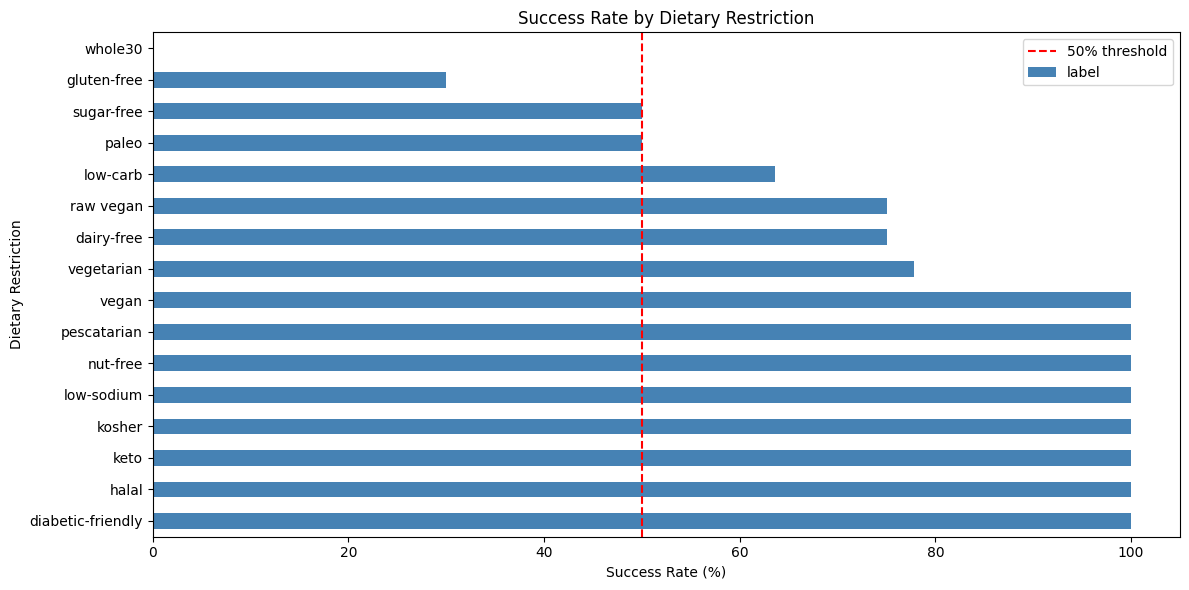

In [10]:
# Calculate success rate by dietary restriction
success_rate = labeled_data.groupby('dietary_restriction')['label'].apply(
    lambda x: (x == 'PASS').sum() / len(x) * 100
).sort_values(ascending=False)

print("Success Rate (% PASS) by Dietary Restriction:")
print(success_rate)

# Visualize
plt.figure(figsize=(12, 6))
success_rate.plot(kind='barh', color='steelblue')
plt.title('Success Rate by Dietary Restriction')
plt.xlabel('Success Rate (%)')
plt.ylabel('Dietary Restriction')
plt.axvline(x=50, color='red', linestyle='--', label='50% threshold')
plt.legend()
plt.tight_layout()
plt.show()

## Step 7: Explore Edge Cases and Ambiguous Examples

Let's look for potentially interesting or challenging examples.

### What are edge cases?
**Edge cases** are unusual or boundary situations that might be tricky to evaluate. For example:
- Queries with multiple dietary restrictions
- Vague or ambiguous requests
- Contradictory requirements ("vegan but wants honey")

In [11]:
# Look for queries that might mention multiple restrictions or be ambiguous
# (This is a simple heuristic - look for queries with certain keywords)

print("Looking for potentially ambiguous queries...\n")

ambiguous_keywords = ['ish', 'kind of', 'not too', 'mostly', 'pretty', 'somewhat', 'flexible']

ambiguous_examples = labeled_data[
    labeled_data['query'].str.lower().str.contains('|'.join(ambiguous_keywords), na=False)
]

print(f"Found {len(ambiguous_examples)} potentially ambiguous queries:")
if len(ambiguous_examples) > 0:
    for idx, row in ambiguous_examples.head(5).iterrows():
        print(f"\n{'-'*80}")
        print(f"Query: {row['query']}")
        print(f"Restriction: {row['dietary_restriction']}")
        print(f"Label: {row['label']}")
        print(f"Reasoning: {row['reasoning'][:200]}...")

Looking for potentially ambiguous queries...

Found 12 potentially ambiguous queries:

--------------------------------------------------------------------------------
Query: Something not too carb-y for dinner
Restriction: low-carb
Label: PASS
Reasoning: The recipe for Garlic Butter Shrimp with Zucchini Noodles is well-suited for a low-carb dietary restriction. The primary ingredients, shrimp and zucchini, are both low in carbohydrates. Zucchini noodl...

--------------------------------------------------------------------------------
Query: Something keto-ish but not super strict
Restriction: keto
Label: PASS
Reasoning: The recipe for Garlic Butter Cauliflower Rice adheres to the keto dietary restriction. The primary ingredient, cauliflower, is low in carbohydrates and suitable for a keto diet. The use of unsalted bu...

--------------------------------------------------------------------------------
Query: I'm pescatarian but I hate fish. Can you give me a seafood pasta recipe?
Rest

## Step 8: Summary Statistics

Let's create a summary of what we've learned about the dataset.

In [13]:
print("="*80)
print("DATASET SUMMARY")
print("="*80)

total_examples = len(labeled_data)
pass_count = len(labeled_data[labeled_data['label'] == 'PASS'])
fail_count = len(labeled_data[labeled_data['label'] == 'FAIL'])
num_restrictions = labeled_data['dietary_restriction'].nunique()

print(f"\n📊 Total Examples: {total_examples}")
print(f"✅ PASS Examples: {pass_count} ({pass_count/total_examples*100:.1f}%)")
print(f"❌ FAIL Examples: {fail_count} ({fail_count/total_examples*100:.1f}%)")
print(f"🥗 Unique Dietary Restrictions: {num_restrictions}")

print(f"\n📈 Top 5 Most Common Restrictions:")
print(labeled_data['dietary_restriction'].value_counts().head())

print(f"\n📉 Restrictions with Lowest Success Rates:")
print(success_rate.tail())

print(f"\n📈 Restrictions with Highest Success Rates:")
print(success_rate.head())

DATASET SUMMARY

📊 Total Examples: 101
✅ PASS Examples: 75 (74.3%)
❌ FAIL Examples: 26 (25.7%)
🥗 Unique Dietary Restrictions: 16

📈 Top 5 Most Common Restrictions:
dietary_restriction
vegetarian     18
vegan          11
low-carb       11
gluten-free    10
paleo          10
Name: count, dtype: int64

📉 Restrictions with Lowest Success Rates:
dietary_restriction
low-carb       63.636364
paleo          50.000000
sugar-free     50.000000
gluten-free    30.000000
whole30         0.000000
Name: label, dtype: float64

📈 Restrictions with Highest Success Rates:
dietary_restriction
diabetic-friendly    100.0
halal                100.0
keto                 100.0
kosher               100.0
low-sodium           100.0
Name: label, dtype: float64


## Step 9: Your Observations

### 🤔 Reflection Exercise

Based on what you've explored, answer these questions:

1. **Data Quality**: Do the labels seem consistent and well-reasoned?
2. **Balance**: Is the dataset balanced between PASS and FAIL? Does this matter?
3. **Coverage**: Are all important dietary restrictions represented?
4. **Challenges**: Which dietary restrictions seem most challenging for the bot?
5. **Edge Cases**: Did you find any particularly tricky or ambiguous examples?

Write your observations in the cell below:

### Your Observations:

**Data Quality:**
- Some of the labels seem poorly reasoned, ex one of them flagged feta as a possible contaminant for gluten-free restriction, which it should not be

**Balance:**
- [Write your observations here]

**Coverage:**
- [Write your observations here]

**Challenges:**
- [Write your observations here]

**Edge Cases:**
- [Write your observations here]

## Next Steps

Now that you understand the labeled data structure, you're ready to move on to **Notebook 02: Split Data**!

In the next notebook, you'll:
- Learn about train/dev/test splits and why they matter
- Implement a data splitting strategy
- Ensure your splits are representative of the full dataset
- Save your splits for use in later notebooks